# Лабораторная работа №4
## Q-обучение (Q-Learning)





In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random
import gymnasium as gym

## Реализация QLearningAgent
Формула обновления:
Q(s,a) ← (1−α)Q(s,a) + α(r + γ max_a' Q(s',a'))

In [2]:
# Класс реализует табличный алгоритм Q-learning
class QLearningAgent:
    def __init__(self, alpha, epsilon, discount, get_legal_actions):
        self.get_legal_actions = get_legal_actions
        self._qvalues = defaultdict(lambda: defaultdict(lambda: 0.0))
        self.alpha = alpha
        self.epsilon = epsilon
        self.discount = discount

    def get_qvalue(self, state, action):
        return self._qvalues[state][action]

    def set_qvalue(self, state, action, value):
        self._qvalues[state][action] = value

    def get_value(self, state):
        actions = self.get_legal_actions(state)
        if not actions:
            return 0.0
        return max(self.get_qvalue(state, a) for a in actions)

    def update(self, state, action, reward, next_state):
        current_q = self.get_qvalue(state, action)
        next_value = self.get_value(next_state)
        target = reward + self.discount * next_value
        new_q = (1 - self.alpha) * current_q + self.alpha * target
        self.set_qvalue(state, action, new_q)

    def get_best_action(self, state):
        actions = self.get_legal_actions(state)
        if not actions:
            return None
        best_value = self.get_value(state)
        best_actions = [a for a in actions if self.get_qvalue(state, a) == best_value]
        return random.choice(best_actions)

    def get_action(self, state):
        actions = self.get_legal_actions(state)
        if not actions:
            return None
        if random.random() < self.epsilon:
            return random.choice(actions)
        return self.get_best_action(state)

# Все Q-значения хранятся в словаре словарей: Q[state][action]
# Это позволяет динамически расширять таблицу при появлении новых состояний.


## Обучение на Taxi-v3

In [3]:
env = gym.make('Taxi-v3')
n_actions = env.action_space.n

agent = QLearningAgent(0.5, 0.25, 0.99, lambda s: range(n_actions))

def play_and_train(env, agent, t_max=10000):
    total_reward = 0
    s, _ = env.reset()
    for _ in range(t_max):
        a = agent.get_action(s)
        next_s, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated
        agent.update(s, a, r, next_s)
        s = next_s
        total_reward += r
        if done:
            break
    return total_reward

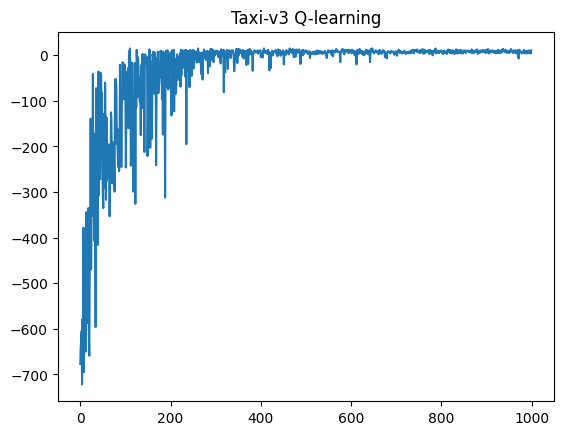

In [4]:
rewards = []
for i in range(1000):
    rewards.append(play_and_train(env, agent))
    agent.epsilon *= 0.99

plt.plot(rewards)
plt.title('Taxi-v3 Q-learning')
plt.show()

## Дискретизация состояний CartPole

In [ ]:
class Binarizer(gym.ObservationWrapper):
    def observation(self, state):
        state = np.array([
            round(state[0], 1),
            round(state[1], 1),
            round(state[2], 2),
            round(state[3], 1)
        ])
        return tuple(state)

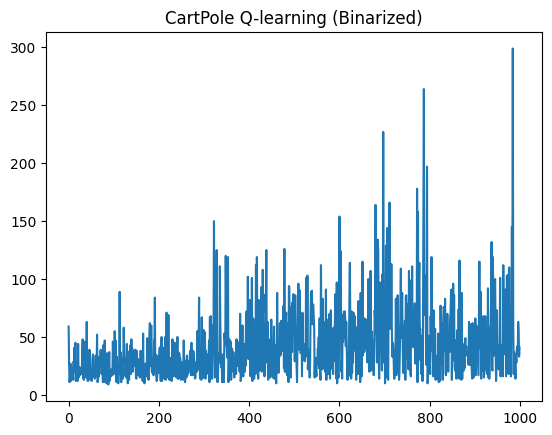

In [ ]:
env_cp = Binarizer(gym.make('CartPole-v1'))
n_actions_cp = env_cp.action_space.n

agent_cp = QLearningAgent(0.5, 0.3, 0.99, lambda s: range(n_actions_cp))

rewards_cp = []
for i in range(1000):
    rewards_cp.append(play_and_train(env_cp, agent_cp))
    agent_cp.epsilon *= 0.995

plt.plot(rewards_cp)
plt.title('CartPole Q-learning (Binarized)')
plt.show()

# Анализ проделанной работы

## 1. Что делает алгоритм Q-learning
Q-learning — это алгоритм обучения с подкреплением, который учится выбирать лучшие действия,
опираясь только на полученные награды. Он постепенно запоминает, насколько выгодно выполнять
определённое действие в конкретном состоянии.

После каждого шага значение Q(s, a) обновляется с учётом:
1) текущей награды,
2) оценки будущих наград,
3) коэффициента дисконтирования γ.

Таким образом агент постепенно приближается к оптимальной стратегии.

## 2. Обучение в среде Taxi-v3
Taxi-v3 — полностью дискретная среда, поэтому табличный Q-learning подходит для неё идеально.
В начале обучения агент действует почти случайно и получает большие отрицательные награды.
По мере накопления опыта он начинает находить более короткие и правильные пути к цели,
поэтому средняя награда постепенно растёт.

Параметр epsilon отвечает за исследование: сначала агент исследует среду активно,
а затем всё чаще использует уже найденную стратегию.

## 3. Обучение в CartPole
CartPole отличается тем, что состояния в ней непрерывные.
Так как табличный метод не может работать с непрерывными значениями напрямую,
была выполнена дискретизация — округление координат состояния.

Это уменьшает количество возможных состояний и позволяет использовать Q-таблицу.
Однако слишком грубая дискретизация может ухудшить точность обучения,
поэтому важно подобрать разумный уровень округления.

## 4. Влияние гиперпараметров
1) alpha определяет, насколько быстро обновляются значения Q.
2) gamma показывает, насколько важны будущие награды.
3) epsilon регулирует баланс между исследованием и использованием.

Правильный подбор этих параметров напрямую влияет на скорость и стабильность обучения.

## 5. Итог
В работе реализован классический табличный Q-learning.
Агент успешно обучается в дискретной среде и демонстрирует рост средней награды.
Также показано, что после дискретизации состояний алгоритм можно применять
и к средам с непрерывным пространством состояний.
